<a href="https://colab.research.google.com/github/vinayreddy17/Crud-frontend/blob/main/practice1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1

In [1]:
# Install packages
!pip install ase scikit-learn tqdm

# Import libraries
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import re
from tqdm import tqdm
from google.colab import files
from ase.io import read
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 27.8 MB/s eta 0:00:00


In [2]:
# Path to ZIP file
zip_path = files.upload()
zip_path = list(zip_path.keys())[0]
# Extract zip file
extract_dir = "/content/TiO2_unzipped"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Path to the folder containing .xsf files
xsf_folder_path = os.path.join(extract_dir, "data-set-2016-TiO2")

# List all .xsf files
file_list = sorted([
    f for f in os.listdir(xsf_folder_path)
    if f.endswith(".xsf") and not f.startswith('.')
])

print("Total .xsf files found:", len(file_list))
print("First 3 files:", file_list[:3])


Saving data-set-2016-TiO2.zip to data-set-2016-TiO2 (1).zip
Total .xsf files found: 7815
First 3 files: ['structure0001.xsf', 'structure0002.xsf', 'structure0003.xsf']


In [3]:
#  Regex pattern to extract energy from the first comment line
energy_pattern = re.compile(r'#\s*total energy\s*=\s*([-]?[0-9]+\.[0-9]+)\s*eV')

X, y = [], []

def compute_features(atoms):
    """
    Create a flat feature vector:
    [atomic_number_1, x1, y1, z1, atomic_number_2, x2, y2, z2, ...]
    """
    z = atoms.get_atomic_numbers()
    pos = atoms.get_positions()
    features = []
    for zi, pi in zip(z, pos):
        features.extend([zi] + list(pi))
    return np.array(features)

# Read and process .xsf files
for file in tqdm(file_list[:7815]):  # Change 1000 to use more files
    full_path = os.path.join(xsf_folder_path, file)
    try:
        # Step 1: Read energy from the comment
        with open(full_path, 'r') as f:
            lines = f.readlines()
            energy = None
            for line in lines:
                match = energy_pattern.search(line)
                if match:
                    energy = float(match.group(1))
                    break

        # Step 2: If energy found, extract features
        if energy is not None:
            atoms = read(full_path)
            features = compute_features(atoms)
            X.append(features)
            y.append(energy)
        else:
            print(f" Energy not found in: {file}")
    except Exception as e:
        print(f" Skipping {file} due to error: {e}")


100%|██████████| 7815/7815 [00:09<00:00, 794.92it/s]


In [4]:
# Pad feature vectors so all have same length
max_len = max(len(f) for f in X)
X_padded = np.array([np.pad(f, (0, max_len - len(f))) for f in X])
y = np.array(y)

# Scale features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_padded)

# Display as DataFrame for easier inspection
df = pd.DataFrame(X_scaled)
df['energy'] = y
print("🔎 Sample data:")
df.head()

🔎 Sample data:


,0,1,2,3,4,5,6,7,8,9,...,371,372,373,374,375,376,377,378,379,energy
0,0.0,1.199580,1.302045,-0.345386,0.0,0.714214,0.131794,-0.461546,0.552368,-0.434845,...,-0.076089,-0.076102,-0.068123,-0.076102,-0.076101,-0.051907,-0.051907,-0.051907,-0.051907,-19960.661733
1,0.0,1.204062,1.305079,-0.332546,0.0,0.718699,0.121573,-0.465908,0.552368,-0.439412,...,-0.076089,-0.076102,-0.068123,-0.076102,-0.076101,-0.051907,-0.051907,-0.051907,-0.051907,-19960.695268
2,0.0,1.208361,1.308314,-0.317525,0.0,0.722955,0.112735,-0.469303,0.552368,-0.442302,...,-0.076089,-0.076102,-0.068123,-0.076102,-0.076101,-0.051907,-0.051907,-0.051907,-0.051907,-19960.758117
3,0.0,1.211995,1.311724,-0.300673,0.0,0.726244,0.105785,-0.471618,0.552368,-0.443309,...,-0.076089,-0.076102,-0.068123,-0.076102,-0.076101,-0.051907,-0.051907,-0.051907,-0.051907,-19960.785979
4,0.0,1.214863,1.315332,-0.282323,0.0,0.728399,0.101009,-0.472471,0.552368,-0.442368,...,-0.076089,-0.076102,-0.068123,-0.076102,-0.076101,-0.051907,-0.051907,-0.051907,-0.051907,-19960.741945


In [5]:
#Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 6252
Testing samples: 1563


In [6]:
# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(" Model training complete.")


 Model training complete.


In [7]:
# Predict on test set
y_pred = model.predict(X_test)

# Compute metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f} eV")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 6.5016 eV
R² Score: 0.9995


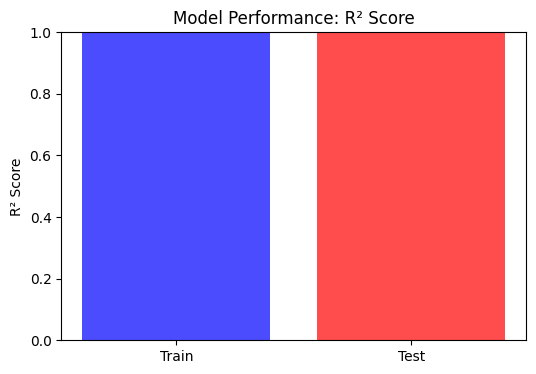

In [8]:
from sklearn.metrics import r2_score

# Compute R^2 score
r2_train = r2_score(y_train, model.predict(X_train))
r2_test = r2_score(y_test, model.predict(X_test))

# Plot R^2 scores
plt.figure(figsize=(6, 4))
plt.bar(["Train", "Test"], [r2_train, r2_test], color=["blue", "red"], alpha=0.7)
plt.ylim(0, 1)  # R^2 ranges from 0 to 1 (or negative if model is bad)
plt.ylabel("R² Score")
plt.title("Model Performance: R² Score")
plt.show()

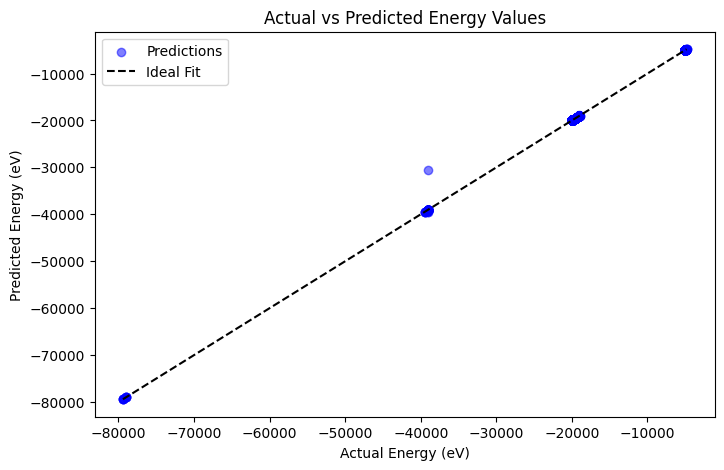

In [9]:
# Scatter plot of Actual vs Predicted values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, model.predict(X_test), alpha=0.5, color='blue', label="Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--', label="Ideal Fit")
plt.xlabel('Actual Energy (eV)')
plt.ylabel('Predicted Energy (eV)')
plt.title('Actual vs Predicted Energy Values')
plt.legend()
plt.show()